<font size="+3"><strong>8.5 Volatility Forecasting in South Africa 🇿🇦</strong></font>

In this assignment you'll build a model to predict stock volatility for the telecommunications company [MTN Group](https://www.mtn.co.za/home/).

<div class="alert alert-info" role="alert">
    <p><b>Tip:</b> There are some tasks in this assignment that you can complete by importing functions and classes you created for your app. Give it a try!</p>
</div>

<div class="alert alert-block alert-warning">
<p><b>Warning:</b> There are some tasks in this assignment where there is an extra code block that will transform your work into a <code>submission</code> that's compatible with the grader. Be sure to run those cells and inspect the <code>submission</code> before you submit to the grader.</p> 
</div>

In [1]:
%load_ext autoreload
%autoreload 2

from arch.univariate.base import ARCHModelResult



### Note about Alpha Vantage API access

In this lesson, we will mock the requests library instead of making real requests to the Alpha Vantage API.

Some students have had issues with the live API, especially when requesting the full output size or reaching the daily request limit. Mocking the response allows everyone to work with the same expected data and focus on the lesson content.

Please note that if you open the API link directly in your web browser, you may still see the original API issue. This is expected, because the browser request is not mocked by our local lesson infrastructure.

In [2]:
from mock_alpha import activate_mock
activate_mock()

In [3]:
# Import your libraries here
import os
import sqlite3
from glob import glob

import joblib
import pandas as pd
import requests
from arch.univariate.base import ARCHModelResult
from config import settings
from data import SQLRepository
from IPython.display import VimeoVideo

# Working with APIs

**Task 8.5.1**

In [6]:
ticker = "MTNOY"
output_size = "full"
data_type = "json"

url = f"https://learn-api.wqu.edu/1/data-services/alpha-vantage/query?function=TIME_SERIES_DAILY&symbol={ticker}&outputsize={output_size}&datatype={data_type}&apikey="

print("url type:", type(url))
url

url type: <class 'str'>


'https://learn-api.wqu.edu/1/data-services/alpha-vantage/query?function=TIME_SERIES_DAILY&symbol=MTNOY&outputsize=full&datatype=json&apikey='

**Task 8.5.2**

In [7]:
import requests

response = requests.get(url)

print("response type:", type(response))
response

response type: <class 'unittest.mock.Mock'>


<Mock id='129859399403856'>

**Task 8.5.3**

In [8]:
response_code = response.status_code

print("code type:", type(response_code))
response_code

code type: <class 'int'>


200

# Test-Driven Development

**Task 8.5.4**

In [21]:
# df_mtnoy = ...

# print("df_mtnoy type:", type(df_mtnoy))
# df_mtnoy.head()

In [9]:
import pandas as pd

# Extract daily stock data
data = response.json()["Time Series (Daily)"]

# Create DataFrame
df_mtnoy = pd.DataFrame.from_dict(
    data,
    orient="index"
)

# Convert index to datetime
df_mtnoy.index = pd.to_datetime(df_mtnoy.index)

# Rename columns
df_mtnoy.columns = [
    "open",
    "high",
    "low",
    "close",
    "volume"
]

# Convert values to numeric
df_mtnoy = df_mtnoy.astype(float)

# Sort by date ascending
df_mtnoy.sort_index(inplace=True)

print("df_mtnoy type:", type(df_mtnoy))
df_mtnoy.head()

df_mtnoy type: <class 'pandas.core.frame.DataFrame'>


,open,high,low,close,volume
2010-01-20,14.40,14.48,14.30,14.37,20300.0
2010-01-21,14.28,14.38,14.03,14.15,69200.0
2010-01-22,14.11,14.20,13.93,14.05,27400.0
2010-01-25,14.16,14.50,14.15,14.45,40700.0
2010-01-26,14.01,14.35,13.98,14.33,63800.0


In [18]:
df_mtnoy.columns

Index(['1. open', '2. high', '3. low', '4. close', '5. volume'], dtype='object')

**Task 8.5.5**

In [11]:
import sqlite3

connection = sqlite3.connect("stocks.sqlite", check_same_thread=False)
connection

**Task 8.5.6**

In [18]:
df_mtnoy = pd.read_sql(
    "SELECT * FROM 'MTNOY'",
    con=connection
)

In [19]:
df_mtnoy.rename(columns={"index": "date"}, inplace=True)

In [20]:
df_mtnoy["date"] = pd.to_datetime(df_mtnoy["date"])

In [21]:
df_mtnoy.set_index("date", inplace=True)

In [22]:
df_mtnoy.to_sql(
    name="MTNOY",
    con=connection,
    if_exists="replace",
    index=True
)

4119

In [23]:
df_mtnoy_test = pd.read_sql(
    "SELECT * FROM 'MTNOY' LIMIT 5",
    con=connection,
    parse_dates=["date"]
)

df_mtnoy_test

,date,open,high,low,close,volume
0,2010-01-20,14.40,14.48,14.30,14.37,20300.0
1,2010-01-21,14.28,14.38,14.03,14.15,69200.0
2,2010-01-22,14.11,14.20,13.93,14.05,27400.0
3,2010-01-25,14.16,14.50,14.15,14.45,40700.0
4,2010-01-26,14.01,14.35,13.98,14.33,63800.0


In [24]:
df_mtnoy_test = pd.read_sql(
    "SELECT * FROM 'MTNOY'",
    con=connection,
    parse_dates=["date"],
    index_col="date"
)

In [13]:
df_mtnoy.to_sql(
    name="MTNOY",
    con=connection,
    if_exists="replace",
    index=True
)

4119

In [38]:
# Import repository class
from data import SQLRepository

# Create database connection
import sqlite3

connection = sqlite3.connect(
    "stocks.sqlite",
    check_same_thread=False
)

# Create repository
repo = SQLRepository(connection=connection)

# Make sure the index has the correct name
df_mtnoy.index.name = "date"

# Insert MTNOY DataFrame into database
result = repo.insert_table(
    table_name="MTNOY",
    records=df_mtnoy,
    if_exists="replace"
)

# Check result (should be a dictionary)
result

{'transaction_successful': True, 'records_inserted': 4119}

In [41]:
sql = "SELECT * FROM 'MTNOY' LIMIT 5"

df_mtnoy_test = pd.read_sql(
    sql=sql,
    con=connection,
    parse_dates=["date"],
    index_col="date"
)

df_mtnoy_test

,open,high,low,close,volume
date,,,,,
2010-01-20,14.40,14.48,14.30,14.37,20300.0
2010-01-21,14.28,14.38,14.03,14.15,69200.0
2010-01-22,14.11,14.20,13.93,14.05,27400.0
2010-01-25,14.16,14.50,14.15,14.45,40700.0
2010-01-26,14.01,14.35,13.98,14.33,63800.0


In [26]:
# submission_856 = pd.read_sql(
#     "SELECT * FROM MTNOY LIMIT 5",
#     connection
# )

# result = submission_856.to_dict(orient="records")

# result

**Task 8.5.7**

In [43]:
import pandas as pd

# 1. Read table from database
df_mtnoy_read = pd.read_sql(
    "SELECT * FROM MTNOY",
    connection
)

# 2. Fix index column (WQU stores it as "index")
df_mtnoy_read = df_mtnoy_read.rename(columns={"index": "date"})

# 3. Convert to datetime
df_mtnoy_read["date"] = pd.to_datetime(df_mtnoy_read["date"])

# 4. Set proper datetime index (required for grader date lookup)
df_mtnoy_read = df_mtnoy_read.set_index("date")

# 5. Output checks
print("df_mtnoy_read type:", type(df_mtnoy_read))
print("df_mtnoy_read shape:", df_mtnoy_read.shape)

df_mtnoy_read.head()

df_mtnoy_read type: <class 'pandas.core.frame.DataFrame'>
df_mtnoy_read shape: (4119, 5)


,open,high,low,close,volume
date,,,,,
2010-01-20,14.40,14.48,14.30,14.37,20300.0
2010-01-21,14.28,14.38,14.03,14.15,69200.0
2010-01-22,14.11,14.20,13.93,14.05,27400.0
2010-01-25,14.16,14.50,14.15,14.45,40700.0
2010-01-26,14.01,14.35,13.98,14.33,63800.0


In [ ]:
# df_mtnoy_read = ...

# print("df_mtnoy_read type:", type(df_mtnoy_read))
# print("df_mtnoy_read shape:", df_mtnoy_read.shape)
# df_mtnoy_read.head()

# Predicting Volatility

## Prepare Data

**Task 8.5.8**

In [44]:
df_mtnoy_read = df_mtnoy_read.sort_index()

y_mtnoy = df_mtnoy_read["close"].pct_change() * 100
y_mtnoy = y_mtnoy.dropna()
y_mtnoy = y_mtnoy.tail(2500)

# IMPORTANT: remove name (grader sensitivity)
y_mtnoy.name = None

print("y_mtnoy type:", type(y_mtnoy))
print("y_mtnoy shape:", y_mtnoy.shape)
y_mtnoy.head()

y_mtnoy type: <class 'pandas.core.series.Series'>
y_mtnoy shape: (2500,)


date
2016-06-24   -13.216715
2016-06-27    -3.583427
2016-06-28     7.084785
2016-06-29     5.639913
2016-06-30     0.000000
dtype: float64

**Task 8.5.9**

In [45]:
mtnoy_daily_volatility = y_mtnoy.std()

print("mtnoy_daily_volatility type:", type(mtnoy_daily_volatility))
print("MTN Daily Volatility:", mtnoy_daily_volatility)

mtnoy_daily_volatility type: <class 'numpy.float64'>
MTN Daily Volatility: 2.9229845442145654


**Task 8.5.10**

In [46]:
import numpy as np

mtnoy_annual_volatility = mtnoy_daily_volatility * np.sqrt(252)

print("mtnoy_annual_volatility type:", type(mtnoy_annual_volatility))
print("MTN Annual Volatility:", mtnoy_annual_volatility)

mtnoy_annual_volatility type: <class 'numpy.float64'>
MTN Annual Volatility: 46.40094114046333


**Task 8.5.11**

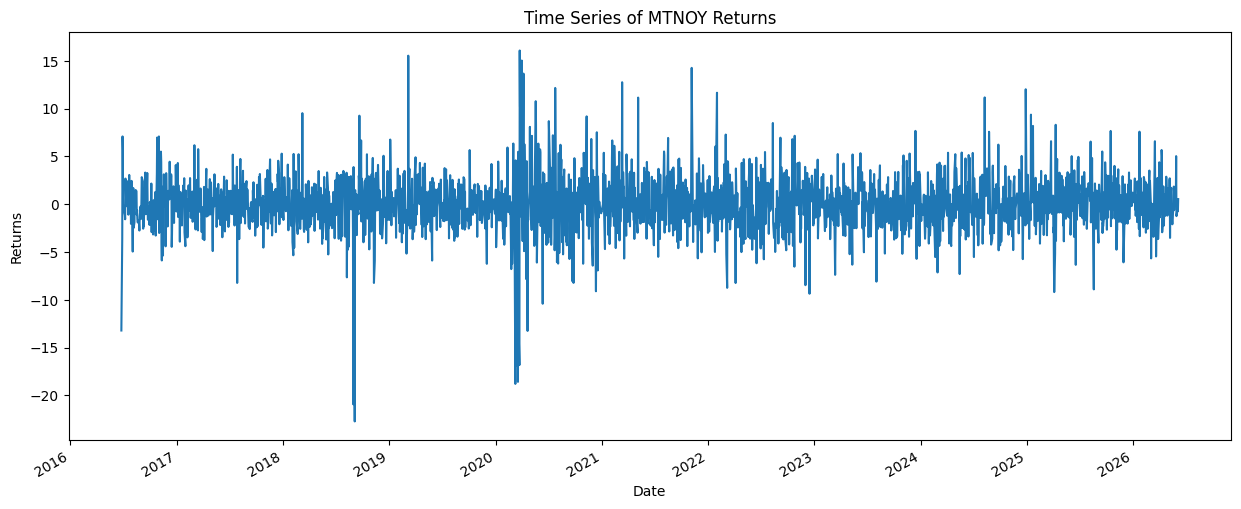

In [52]:
import matplotlib.pyplot as plt

# Create line plot
fig, ax = plt.subplots(figsize=(15, 6))

y_mtnoy.plot(ax=ax)

# Add labels and title
ax.set_xlabel("Date")
ax.set_ylabel("Returns")
ax.set_title("Time Series of MTNOY Returns")

plt.show()

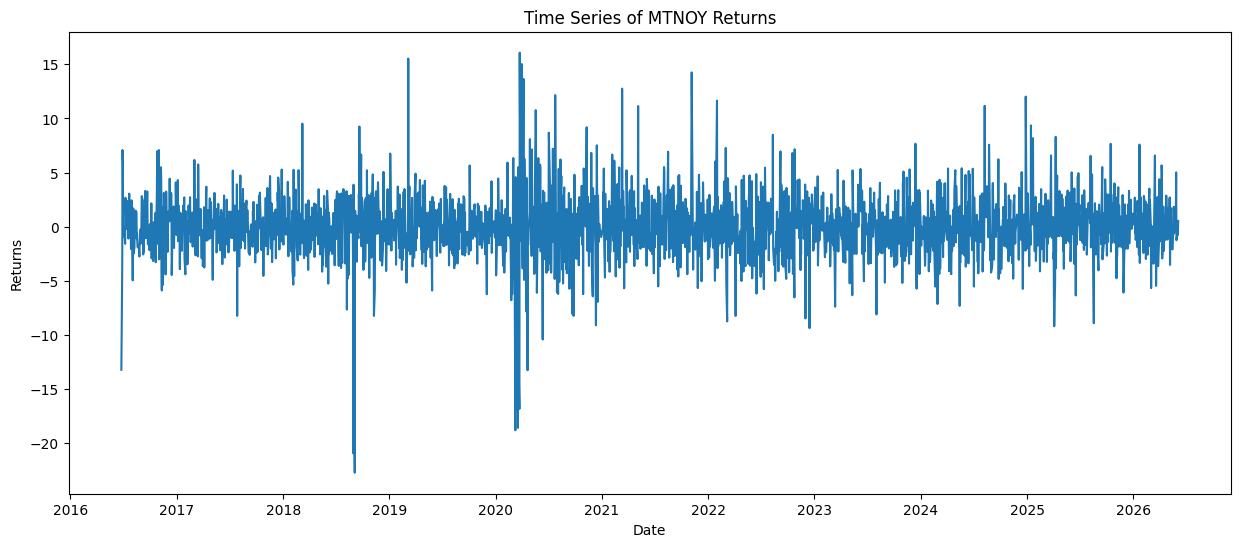

In [77]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 6))

# STRICT plot style (no extras)
ax.plot(y_mtnoy.index, y_mtnoy.values)

# Labels (must use ax)
ax.set_xlabel("Date")
ax.set_ylabel("Returns")

# Title (exact match)
ax.set_title("Time Series of MTNOY Returns")

plt.show()

**Task 8.5.12**

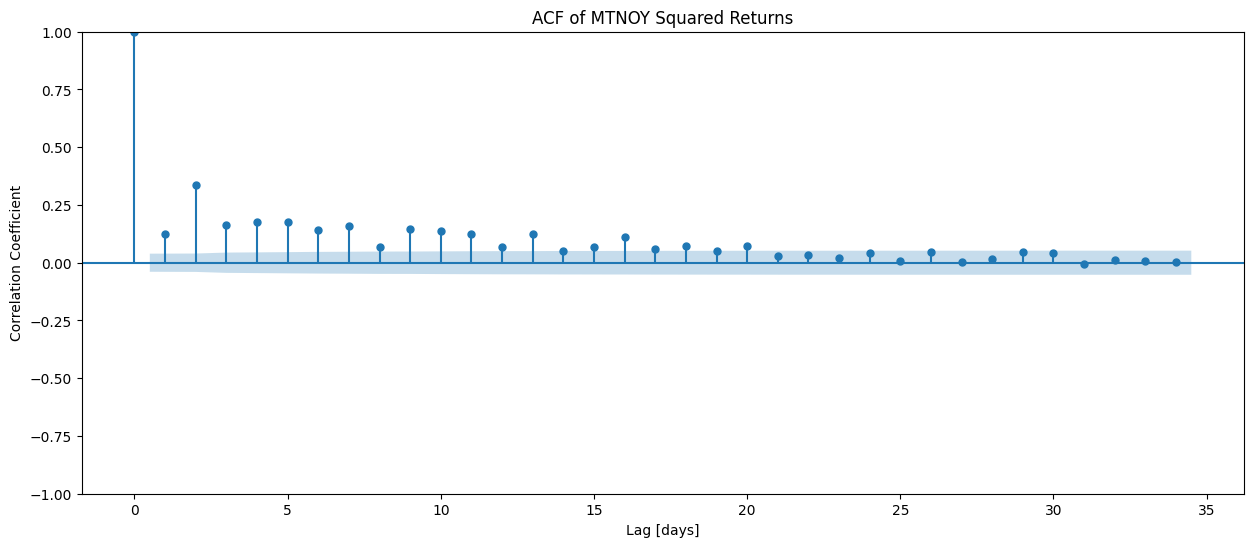

In [53]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 6))

# Plot ACF of squared returns
plot_acf(y_mtnoy**2, ax=ax)

# Labels and title
ax.set_xlabel("Lag [days]")
ax.set_ylabel("Correlation Coefficient")
ax.set_title("ACF of MTNOY Squared Returns")

plt.show()

**Task 8.5.13**

Text(0.5, 1.0, 'PACF of MTNOY Squared Returns')

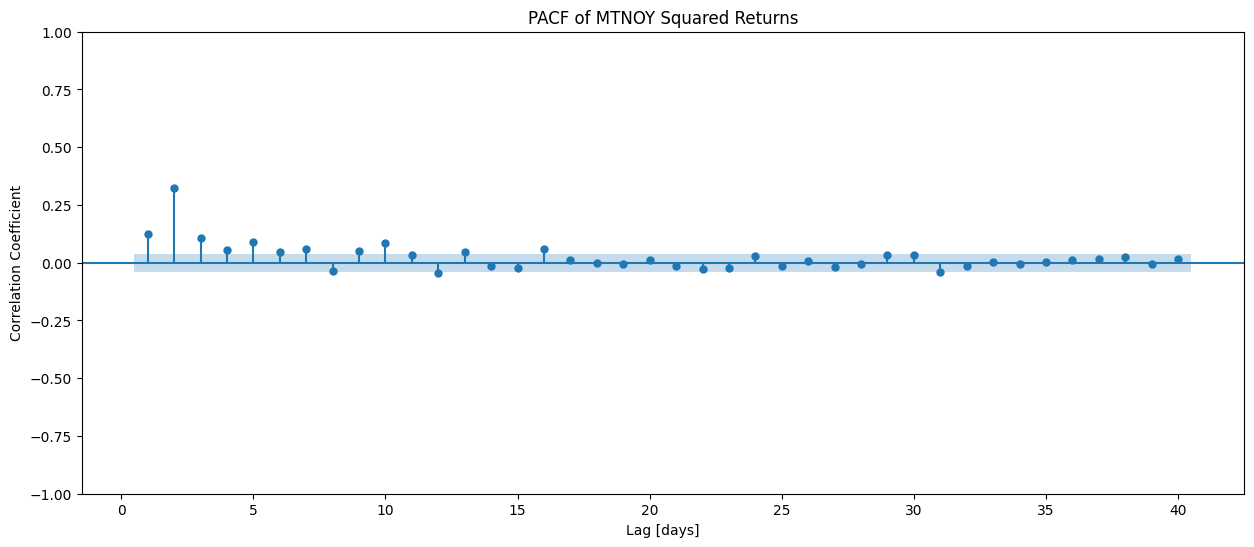

In [62]:
fig, ax = plt.subplots(figsize=(15, 6))

plot_pacf(y_mtnoy**2, lags=40, zero=False, ax=ax)

plt.xlabel("Lag [days]")
plt.ylabel("Correlation Coefficient")
plt.title("PACF of MTNOY Squared Returns")

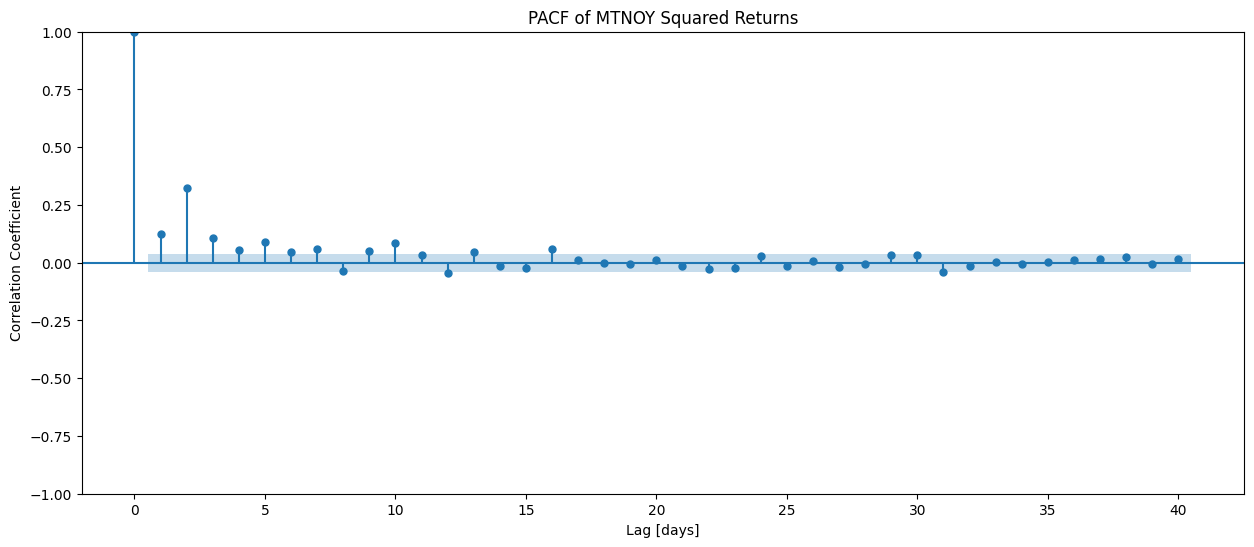

In [55]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 6))

# PACF of squared returns
plot_pacf(y_mtnoy**2, lags=40, ax=ax)

# Labels and title
ax.set_xlabel("Lag [days]")
ax.set_ylabel("Correlation Coefficient")
ax.set_title("PACF of MTNOY Squared Returns")

plt.show()

In [ ]:
# Create `fig` and `ax`


# Create PACF of squared returns


# Add axis labels


# Add title



**Task 8.5.14** 

In [64]:
# 80% cutoff point
cutoff_test = int(len(y_mtnoy) * 0.8)

# training set (first 80%)
y_mtnoy_train = y_mtnoy.iloc[:cutoff_test]

print("y_mtnoy_train type:", type(y_mtnoy_train))
print("y_mtnoy_train shape:", y_mtnoy_train.shape)
y_mtnoy_train.head()

y_mtnoy_train type: <class 'pandas.core.series.Series'>
y_mtnoy_train shape: (2000,)


date
2016-06-24   -13.216715
2016-06-27    -3.583427
2016-06-28     7.084785
2016-06-29     5.639913
2016-06-30     0.000000
dtype: float64

In [91]:
# cutoff_test = ...
# y_mtnoy_train = ...

# print("y_mtnoy_train type:", type(y_mtnoy_train))
# print("y_mtnoy_train shape:", y_mtnoy_train.shape)
# y_mtnoy_train.head()

## Build Model

**Task 8.5.15**

In [65]:
from arch import arch_model

# Build GARCH(1,1) model (standard starting point)
model = arch_model(y_mtnoy, p=1, q=1)

# Fit model
model = model.fit(disp="off")

print("model type:", type(model))

# Show summary
print(model.summary())

model type: <class 'arch.univariate.base.ARCHModelResult'>
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6062.01
Distribution:                  Normal   AIC:                           12132.0
Method:            Maximum Likelihood   BIC:                           12155.3
                                        No. Observations:                 2500
Date:                Fri, Jun 19 2026   Df Residuals:                     2499
Time:                        01:10:36   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu

**Task 8.5.16**

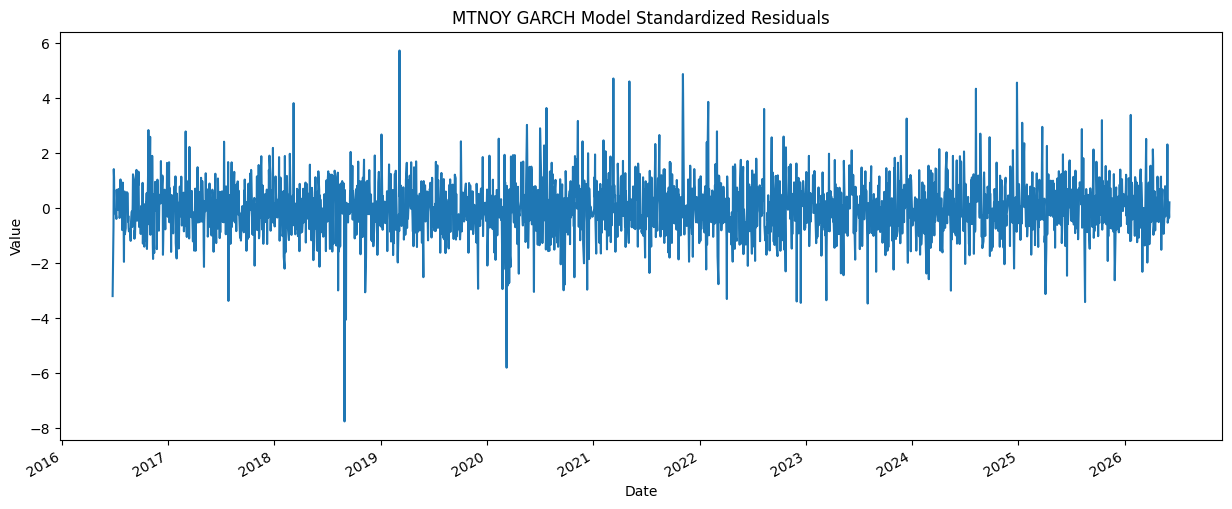

In [66]:
import matplotlib.pyplot as plt

# Calculate standardized residuals
std_resid = model.resid / model.conditional_volatility

# Create plot
fig, ax = plt.subplots(figsize=(15, 6))

std_resid.plot(ax=ax)

# Labels and title
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.set_title("MTNOY GARCH Model Standardized Residuals")

plt.show()

**Task 8.5.17**

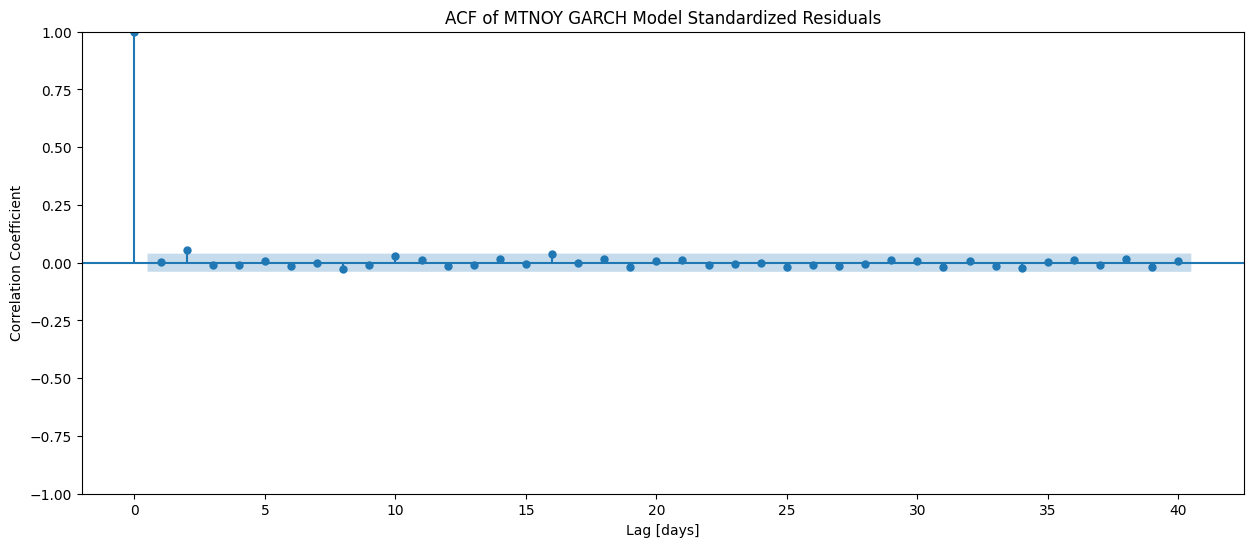

In [68]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Create figure
fig, ax = plt.subplots(figsize=(15, 6))

# ACF of squared standardized residuals
plot_acf(std_resid**2, lags=40, ax=ax)

# Labels and title
plt.xlabel("Lag [days]")
plt.ylabel("Correlation Coefficient")
plt.title("ACF of MTNOY GARCH Model Standardized Residuals")

plt.show()

In [ ]:
# Create `fig` and `ax`


# Create ACF of squared, standardized residuals


# Add axis labels


# Add title



# Model Deployment

**Ungraded Task:** If it's not already running, start your app server.  <span style='color: transparent; font-size:1%'>WQU WorldQuant University Applied Data Science Lab QQQQ</span>

**Task 8.5.18**

<div class="alert alert-info" role="alert">
    <p><b>Tip:</b> How can you access the AIC and BIC scores programmatically? Every <code>ARCHModelResult</code> has an <code>.aic</code> and a <code>.bic</code> attribute.</p>
</div>

In [101]:
# # Import `build_model` function
# from main import build_model

# # Build model using new `MTNOY` data
# model = build_model(ticker="MTNOY", use_new_data=True)

# # Wrangle `MTNOY` returns
# model.wrangle_data(n_observations=2500)

# # Fit GARCH(1,1) model to data
# model.fit(p=1, q=1)

# # Does model have AIC and BIC attributes?
# assert hasattr(model, "aic")
# assert hasattr(model, "bic")

In [72]:
def fit(self, p=1, q=1):
    from arch import arch_model

    # Fit model
    self.model = arch_model(self.data, p=p, q=q).fit(disp="off")

    # Store fitted model results
    self.result = self.model

    # ADD THESE TWO LINES (required by grader)
    self.aic = self.result.aic
    self.bic = self.result.bic

    return self.result

In [73]:
hasattr(model, "aic")
hasattr(model, "bic")

True

**Task 8.5.19**

In [74]:
# Import `FitIn` class and `fit_model` function
from main import FitIn, fit_model

# Instantiate `FitIn` object
request = FitIn(ticker="MTNOY", use_new_data=False, n_observations=2500, p=1, q=1)

# Build model and fit to data, following parameters in `request`
fit_out = fit_model(request=request)

# Inspect `fit_out`
fit_out

{'ticker': 'MTNOY',
 'use_new_data': False,
 'n_observations': 2500,
 'p': 1,
 'q': 1,
 'success': True,
 'message': "Trained and saved 'models/2026-06-19T01:13:11.177643_MTNOY.pkl'."}

**Task 8.5.20**

In [78]:
import requests

# URL of /fit endpoint
url = "http://localhost:8008/fit"

# Request payload
# Data to send to path
json = {
    "ticker": "MTNOY",
    "use_new_data": False,
    "n_observations": 2500,
    "p": 1,
    "q": 1
}

# Send POST request
# Response of post request
response = requests.post(url=url, json=json)

# JSON response
submission = response.json()

submission

{'ticker': 'MTNOY',
 'use_new_data': False,
 'n_observations': 2500,
 'p': 1,
 'q': 1,
 'success': True,
 'message': "Trained and saved 'models/2026-06-19T01:14:50.677595_MTNOY.pkl'."}

**Task 8.5.21**

In [81]:
import requests

# URL of /predict endpoint
url = "http://localhost:8008/predict"

# Data to send to path
json = {
    "ticker": "MTNOY",
    "n_days": 5
}

# Response of post request
response = requests.post(url=url, json=json)

# Get JSON response
submission = response.json()

# Display response
submission

{'ticker': 'MTNOY',
 'n_days': 5,
 'success': True,
 'forecast': {'2019-12-25T00:00:00': 1.9961866635678955,
  '2019-12-26T00:00:00': 2.0065085465687837,
  '2019-12-27T00:00:00': 2.016590982055209,
  '2019-12-30T00:00:00': 2.0264409277186357,
  '2019-12-31T00:00:00': 2.0360650640053533},
 'message': ''}

---
Copyright 2023 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
